# 4. Embedding models — what is actually inside

Notebook 2 showed *how* to use an embedding model: tokenize, forward pass,
pool, normalize. This notebook fills in the gap left open there — *what
kind of model is doing that, and why are there two completely different
flavors of "embedding-like" models in retrieval (bi-encoders and
cross-encoders)?*

The level of detail here is deliberately modest. We won't derive
attention or back-prop. We'll get just enough mental model that:

1. The shapes in notebook 2 stop feeling magical.
2. You can pick the right architecture for a job, instead of grabbing
   whatever the tutorial uses.
3. The reranker in notebook 5 won't surprise you.

## 4.1 What's in a "transformer encoder", at retrieval-relevant resolution

`sentence-transformers/all-MiniLM-L6-v2` is a small **BERT-style encoder**.
The picture you need:

```
          ┌──────────────────────────────────────────────────────┐
   text ──►   tokenizer   ──►   subword IDs   (length L)         │
          │                                                       │
          │   each ID is replaced by a learned vector of size H   │
          │   ──►   embedding matrix lookup                       │
          │                                                       │
          │   6 transformer layers, each refining all L vectors   │
          │   by letting them "look at" one another (self-attn)   │
          │                                                       │
          ▼                                                       │
          one  H-dim vector per token  (the "last hidden state")  │
          └──────────────────────────────────────────────────────┘
                                 │
                                 │   POOL  (mean / [CLS] / max)
                                 ▼
                          one  H-dim vector for the whole input
```

For MiniLM-L6: `L` is up to 512, `H` is 384, the model has 6 transformer
layers and 22M parameters total. The layers are useful for the model but
*not for our story* — what matters is the input/output shape:

> "**text → list of subword IDs → one vector per token → one pooled
> vector for the whole input.**"

That's it. That's the architecture. Everything below is a *different
choice of how to use* this shape.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import torch
from transformers import AutoTokenizer, AutoModel

MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"
tok = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID); model.eval()

# Print the shape of every layer's output for ONE sentence, so you can see
# how the "L tokens, H dims" picture is preserved end to end.
enc = tok("the cat sat on the mat", return_tensors="pt")
with torch.no_grad():
    out = model(**enc, output_hidden_states=True)

print(f"input length L = {enc['input_ids'].shape[1]} tokens, "
      f"hidden size H = {model.config.hidden_size}")
print(f"transformer has {model.config.num_hidden_layers} encoder layers\n")
print("shape of hidden state after each layer (incl. input embeddings):")
for i, h in enumerate(out.hidden_states):
    label = "embedding lookup" if i == 0 else f"layer {i}"
    print(f"  [{label:18s}]  hidden_states[{i}].shape = {tuple(h.shape)}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

input length L = 8 tokens, hidden size H = 384
transformer has 6 encoder layers

shape of hidden state after each layer (incl. input embeddings):
  [embedding lookup  ]  hidden_states[0].shape = (1, 8, 384)
  [layer 1           ]  hidden_states[1].shape = (1, 8, 384)
  [layer 2           ]  hidden_states[2].shape = (1, 8, 384)
  [layer 3           ]  hidden_states[3].shape = (1, 8, 384)
  [layer 4           ]  hidden_states[4].shape = (1, 8, 384)
  [layer 5           ]  hidden_states[5].shape = (1, 8, 384)
  [layer 6           ]  hidden_states[6].shape = (1, 8, 384)


Every layer outputs a tensor of shape `(batch, L, H)`. Nothing about
that shape changes; the *numbers* inside change. The transformer is
just refining a `(L, H)` array of token vectors L times, then we
collapse to a single H-dim vector at the end.

This is the entire architectural budget you need to understand the
next section.

## 4.2 Two ways to score (q, d) — late vs. early interaction

Now we have a small toolbox (`text → vector(s)`). The question is:
*how do we use it to score a (query, document) pair?* Two completely
different answers exist; both are everywhere in production retrieval.

### Bi-encoder (late interaction)

```
   query     ──►  [encoder]  ──►  q_vec  ┐
                                          │── cosine(q_vec, d_vec) ── score
   document  ──►  [encoder]  ──►  d_vec  ┘
```

Encode the two things *independently*; the only "interaction" between
them is the final dot product. Hence **late interaction** — they don't
meet until the very end, after everything else has already happened.

**Critical consequence:** you can pre-compute `d_vec` for every
document *once*, store the matrix, and only pay one forward pass per
*query* at runtime. This is why bi-encoder retrieval can scale to
billions of documents.

### Cross-encoder (early interaction)

```
   [CLS] query [SEP] document [SEP]  ──►  [encoder]  ──►  score (a scalar)
```

Concatenate query and document into a single input and run the
transformer *on both at once*. Every attention layer can look at
*every* (query-token, document-token) pair. Hence **early
interaction** — they meet at the input layer, before any computation.

**Critical consequence:** there's no per-document vector to cache.
For *every* `(q, d)` pair you want to score, you run the full
transformer end-to-end. So cross-encoders are far slower than
bi-encoders, but they typically beat them on accuracy by 3–10 recall
points because they can attend to query-document token interactions.

The reigning recipe in modern retrieval is **both**: a fast
bi-encoder retrieves a coarse top-100, then a slow cross-encoder
reranks down to top-10. We build exactly this in notebook 5.

In [2]:
# Side-by-side runnable demo.
# The bi-encoder is the model we've used all along.
# The cross-encoder we load here is the standard MS MARCO reranker --
# tiny enough (~80MB) to run on CPU, strong enough to be useful.
from sentence_transformers import SentenceTransformer, CrossEncoder

bi    = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
cross = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

print("BI    :", bi)
print()
print("CROSS :", cross)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BI    : SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)

CROSS : CrossEncoder(
  (0): Transformer({'transformer_task': 'sequence-classification', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'logits'}}, 'module_output_name': 'scores', 'architecture': 'BertForSequenceClassification'})
)


In [3]:
# A toy retrieval problem with one tricky distractor.
query = "What does the cat eat?"
docs = [
    "cats are obligate carnivores and need meat in their diet",      # truly relevant
    "the cat sat on the mat",                                         # superficial overlap
    "dogs are descended from wolves",                                 # off-topic
    "tigers and lions are big cats that hunt prey",                   # cat-adjacent
]

# ----- Bi-encoder scoring (late interaction) -----
import numpy as np
q_vec   = bi.encode([query], normalize_embeddings=True, convert_to_numpy=True)[0]
d_vecs  = bi.encode(docs,   normalize_embeddings=True, convert_to_numpy=True)
bi_scores = d_vecs @ q_vec

# ----- Cross-encoder scoring (early interaction) -----
cross_inputs = [[query, d] for d in docs]
cross_scores = cross.predict(cross_inputs)

print(f"{'rank-bi':>8} {'rank-ce':>8} {'cos-bi':>8} {'logit-ce':>10}   doc")
bi_rank    = np.argsort(-bi_scores).argsort()         # 0 = best
cross_rank = np.argsort(-cross_scores).argsort()
for i in range(len(docs)):
    print(f"  d{i}   {bi_rank[i]+1:6d}   {cross_rank[i]+1:6d}   "
          f"{bi_scores[i]:+.3f}    {cross_scores[i]:+.3f}    {docs[i]!r}")

 rank-bi  rank-ce   cos-bi   logit-ce   doc
  d0        1        1   +0.657    +4.642    'cats are obligate carnivores and need meat in their diet'
  d1        3        3   +0.455    -5.888    'the cat sat on the mat'
  d2        4        4   +0.184    -10.378    'dogs are descended from wolves'
  d3        2        2   +0.477    -3.041    'tigers and lions are big cats that hunt prey'


Two things to read off this table:

- **Both** models rank the truly relevant document `d0` first. On a
  small clean example, a bi-encoder is usually enough.
- The interesting difference is in the **margins**. Look at the bi-encoder
  scores: `d0=0.66`, `d3=0.48`, `d1=0.46`. The "actually answers the
  question" document beats "the cat sat on the mat" by just 0.2 cosine
  units. The cross-encoder gives `d0=+4.64` and `d1=-5.89` — a ten-point
  logit gap. Cross-encoders separate close calls much more decisively
  because they can attend to the (query-token, doc-token) interactions
  token by token.

The cross-encoder scores aren't on a probability scale — they're raw
logits — so don't compare them in absolute terms across queries. They're
a *ranking* signal: bigger = more relevant *for this query*.

In the next notebook we'll see exactly when the bi-encoder *does* mis-rank,
and how a cross-encoder reranker fixes it.

### The speed tradeoff, in numbers

Let's time both on the same workload — score one query against a
small corpus. The numbers will differ across machines but the
*ratio* is the point.

In [4]:
import time
import numpy as np

# A bigger pool to make the timing visible -- 100 documents.
N = 100
pool = [docs[i % len(docs)] for i in range(N)]

# -- Bi-encoder: encode each doc ONCE (offline), then 1 query encode + dot product
t0 = time.perf_counter()
D = bi.encode(pool, normalize_embeddings=True, convert_to_numpy=True,
              show_progress_bar=False)
t_index = time.perf_counter() - t0

t0 = time.perf_counter()
q = bi.encode([query], normalize_embeddings=True, convert_to_numpy=True,
              show_progress_bar=False)[0]
bi_scores = D @ q
t_bi_query = time.perf_counter() - t0

# -- Cross-encoder: must score every (query, doc) pair from scratch
t0 = time.perf_counter()
ce_scores = cross.predict([[query, d] for d in pool], show_progress_bar=False)
t_cross = time.perf_counter() - t0

print(f"corpus size N = {N}")
print(f"  bi-encoder INDEX time (one-time, encode all docs)  : {t_index*1000:7.1f} ms")
print(f"  bi-encoder QUERY time (1 enc + matmul)             : {t_bi_query*1000:7.1f} ms")
print(f"  cross-encoder QUERY time (N forward passes)        : {t_cross*1000:7.1f} ms")
print()
print(f"  cross/bi ratio at query time: {t_cross/max(t_bi_query, 1e-9):.0f}x slower")

corpus size N = 100
  bi-encoder INDEX time (one-time, encode all docs)  :   192.3 ms
  bi-encoder QUERY time (1 enc + matmul)             :    11.3 ms
  cross-encoder QUERY time (N forward passes)        :   243.9 ms

  cross/bi ratio at query time: 22x slower


For 100 documents the cross-encoder is already an order of magnitude
slower than the bi-encoder *at query time*. Scale that to 10M documents
and the cross-encoder becomes unusable as a first-stage retriever.

The practical pattern that came out of this tradeoff:

| stage       | architecture   | typical pool size     | objective                |
|-------------|----------------|-----------------------|--------------------------|
| retrieval   | bi-encoder     | 10⁶–10¹⁰ documents     | high recall, cheap       |
| reranking   | cross-encoder  | 50–200 candidates     | high precision, accurate |
| generation  | LLM            | top 3–10 docs in prompt | answer                   |

That's the whole 2-stage retrieval recipe. Notebook 5 implements it.

## 4.3 Pretraining vs. finetuning — and why embedding finetuning is weird

The encoder we just used was *pretrained* on billions of tokens. That
pretraining used **masked language modelling**: hide 15% of the tokens
in a sentence, ask the model to fill them in. Cheap (no labels), and
forces the model to learn what each word *means in context*.

Then comes **finetuning** — adapting the pretrained backbone to your
task. The standard recipe for classification (sentiment analysis,
NER, …) is to bolt a small task-specific head on top of the encoder
and train with **cross-entropy** against labeled examples. Each
training example is *one labeled sentence*.

Embedding-model finetuning is **fundamentally different**. There is
no per-sentence label. Instead, training examples are *pairs*:

- a **positive pair** `(a, b⁺)`: two pieces of text that *mean* the
  same thing (e.g., a question and its answer; a sentence and its
  paraphrase; a query and the doc that satisfies it).
- a **negative**: any other text that *doesn't* match.

The training loss says:

> *Make the embeddings of positive pairs close. Make the embedding of
> each `a` far from the embeddings of all the negatives.*

This is called **contrastive learning**. The most common form is
"InfoNCE" / "in-batch negatives":

$$
\mathcal{L} = -\log \frac{\exp(\mathbf{a}\cdot \mathbf{b}^+ / \tau)}
                          {\sum_{j} \exp(\mathbf{a}\cdot \mathbf{b}_j / \tau)}
$$

where the denominator sums over the true positive *and* every other
example in the batch (used as negatives). $\tau$ is a temperature.

Two things follow from this objective that nothing else in deep
learning shares:

1. **The "label" is just another sentence**, not a class index. That's
   why curating *pairs* (not labels) is most of the work in embedding
   finetuning.
2. **Batch size matters a lot** — bigger batches give more negatives,
   which makes the contrastive task harder and the learned vectors
   sharper. State-of-the-art embedders are trained with batches of
   32k+ pairs.

A toy visualization makes the geometry obvious.

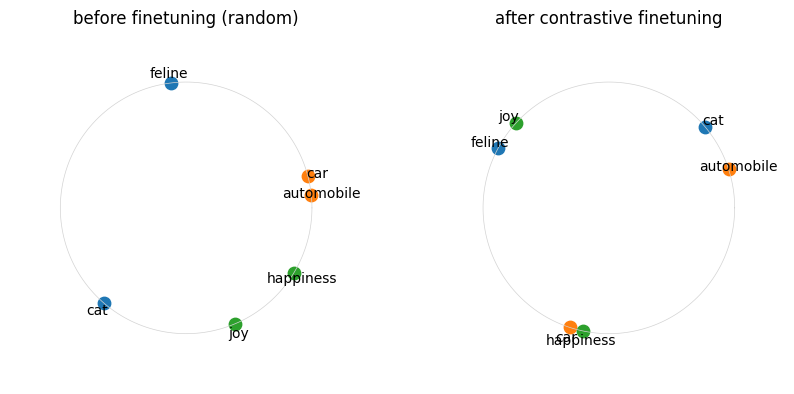

In the right plot, paraphrase pairs (same colour) sit together,
and the three concepts spread out around the unit circle.


In [5]:
# Tiny toy: 3 "concepts", 2 examples per concept, in 2D so we can see it.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# "Before finetuning": all 6 points scattered randomly on the unit circle.
angles_before = rng.uniform(0, 2*np.pi, size=6)
P_before = np.stack([np.cos(angles_before), np.sin(angles_before)], axis=1)

# "After contrastive finetuning": the 2 examples in each concept get pulled
# together; the 3 concept centroids get pushed apart.
concept_angles = np.array([0.5, 2.5, 4.5])    # roughly 120 deg apart
angles_after = np.concatenate([
    concept_angles + rng.normal(0, 0.15, size=3),
    concept_angles + rng.normal(0, 0.15, size=3),
])
P_after = np.stack([np.cos(angles_after), np.sin(angles_after)], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
colors = ["C0", "C0", "C1", "C1", "C2", "C2"]   # 2 of each colour
labels = ["cat", "feline", "car", "automobile", "joy", "happiness"]

for ax, P, title in [(axes[0], P_before, "before finetuning (random)"),
                     (axes[1], P_after,  "after contrastive finetuning")]:
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), color="lightgrey", lw=0.5)
    for (x, y), c, l in zip(P, colors, labels):
        ax.scatter(x, y, color=c, s=80)
        ax.annotate(l, (x*1.08, y*1.08), ha="center", va="center")
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title)
plt.show()
print("In the right plot, paraphrase pairs (same colour) sit together,")
print("and the three concepts spread out around the unit circle.")

Finetuning an embedding model usually does something close to this
picture: it pulls **synonym pairs** in your domain together and pushes
**unrelated** ones apart. That's why a "domain finetune" of an
embedding model can be a couple of orders of magnitude smaller than
pretraining and still move retrieval metrics dramatically (we'll see
that in notebook 5 with a tiny example).

### A sketch of contrastive loss in 6 lines of code

Just to make sure the formula above isn't a black box:

In [6]:
import torch
import torch.nn.functional as F

# Imagine: 4 query/positive pairs already encoded by the encoder.
# (in real training these come from your finetuning data.)
q   = F.normalize(torch.randn(4, 8), dim=1)     # 4 queries,    8-dim vectors
pos = F.normalize(torch.randn(4, 8), dim=1)     # 4 positives,  8-dim vectors

# Similarity of every query to every positive in the batch.
# The diagonal is the "right" pair; everything else is a negative.
logits = q @ pos.T / 0.05                       # tau = 0.05
labels = torch.arange(len(q))                   # row i's positive is column i

loss = F.cross_entropy(logits, labels)
print("loss:", float(loss))
print("interpretation: for each query, push the diagonal up and "
      "everything else in its row down.")

loss: 5.91964054107666
interpretation: for each query, push the diagonal up and everything else in its row down.


That's it. The whole sentence-transformer training pipeline — for
the contrastive losses everyone uses (`MultipleNegativesRanking`,
`CosineSimilarityLoss`, `TripletLoss`) — is variations on these
six lines.

## 4.4 Summary

Three takeaways to carry into the next notebooks:

1. **A "BERT-style encoder" is just** *text → per-token vectors → one
   pooled vector*. The pooling, the normalization, and how you *use*
   the vector are choices on top of that fixed shape.
2. **Two architectures for retrieval, one slow and one fast:**
   bi-encoders (encode separately, dot product at the end) are
   cacheable and scale; cross-encoders (encode jointly, single
   scalar) are accurate but per-pair-expensive. Production systems
   use both — bi-encoder retrieves, cross-encoder reranks.
3. **Embedding-model training is contrastive, not classification.**
   The "label" is another sentence; the loss pulls positive pairs
   together and pushes everything else apart.

Next: **notebook 5** wires up the 2-stage pipeline and quantifies
how much recall a tiny cross-encoder reranker actually buys.